In [1]:
# all libraries that are used in this project
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import os

In [2]:
# load the dataset
file = pd.read_csv(r"D:\data_science\final project data analysis\Pakistan Largest Ecommerce Dataset.csv")
file 

C:\Users\ahmed\AppData\Local\Temp\ipykernel_8484\2457687580.py:2: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  file = pd.read_csv(r"D:\data_science\final project data analysis\Pakistan Largest Ecommerce Dataset.csv")


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## what is  columns mean ?

1- item id id for each product in order

2- sku mean (stock keeping unit) code of product in sotre

3- increment id  number of order

4- created at time and date of create order samre of working date

5- bi status status of order after bi team processing

6- price of one pice 

7- qty_ordered quantity of order

8- grand total price of order after discount and shipping

9- sales commission code related to marketing 

10- customer since first date order of client 

11- fiscal year 

12- mv market value or merchant value = grand total + discount

In [3]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

In [4]:
# this file i didnt know where its come so i dropt it
file.drop(columns=['Unnamed: 21','Unnamed: 22','Unnamed: 23','Unnamed: 24','Unnamed: 25'], inplace=True)            

In [5]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

In [6]:
# i found alot of nulls value in columns
file.dropna(inplace=True)
file.drop_duplicates(inplace=True)

## NOTE
we have 601249 null values and dupilcate data

In [7]:
file.info()

<class 'pandas.core.frame.DataFrame'>
Index: 447326 entries, 0 to 584491
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                447326 non-null  float64
 1   status                 447326 non-null  object 
 2   created_at             447326 non-null  object 
 3   sku                    447326 non-null  object 
 4   price                  447326 non-null  float64
 5   qty_ordered            447326 non-null  float64
 6   grand_total            447326 non-null  float64
 7   increment_id           447326 non-null  object 
 8   category_name_1        447326 non-null  object 
 9   sales_commission_code  447326 non-null  object 
 10  discount_amount        447326 non-null  float64
 11  payment_method         447326 non-null  object 
 12  Working Date           447326 non-null  object 
 13  BI Status              447326 non-null  object 
 14   MV                    447326 non-null  o

In [8]:
file.describe().T

,count,mean,std,min,25%,50%,75%,max
item_id,447326.0,488862.371145,162316.246047,211131.0,350502.5,489394.5,618065.7500,905171.0
price,447326.0,5731.418516,13225.102868,0.0,349.0,850.0,3600.0000,515975.0
qty_ordered,447326.0,1.207810,4.151454,1.0,1.0,1.0,1.0000,1000.0
grand_total,447326.0,7290.916751,67547.990580,-1594.0,849.0,1736.1,6245.0000,17888000.0
discount_amount,447326.0,472.511192,1440.055509,-599.5,0.0,0.0,157.3821,90300.0
Year,447326.0,2016.751038,0.536405,2016.0,2016.0,2017.0,2017.0000,2018.0
Month,447326.0,8.125135,3.279027,1.0,5.0,9.0,11.0000,12.0
Customer ID,447326.0,34895.097803,27360.694015,1.0,9604.0,30861.5,57017.7500,115289.0


## Data Quality Observations & Issues

### 1. Negative Values
Some numerical columns contain negative values.
This could indicate returned or refunded orders.
However, it may also represent data entry or system errors.
Further investigation is required to confirm whether these values should be excluded or adjusted.

---

### 2. Outliers in Quantity Ordered
The average quantity ordered is approximately 1.2 units per order.
However, the maximum quantity reaches 1000 units.
This indicates the presence of extreme outliers, which may represent bulk or wholesale orders.
These outliers can significantly affect statistical measures and should be treated separately or capped.

---

### 3. Zero Values in Price
The price column contains zero values.
A product with a price of zero is not logically valid in a sales dataset.
These records may represent free items, promotions, or data quality issues and need further validation.

---

### 4. High Variance in Grand Total
The mean value of the grand total is around 7,000, while the maximum reaches 17,888.
The standard deviation is very high (67,547), indicating a wide spread in bill values.
This suggests strong variability in order sizes and the possible presence of high-value outliers.


In [9]:
# checking negative grand total values related to status
negative_checks = file[file['grand_total'] < 0]['status'].value_counts()
negative_checks

status
canceled          14
complete          11
refund            11
received           8
order_refunded     3
Name: count, dtype: int64

## NOTE
we found the negative value related to canceled and refund and complete
#and all negative value is 47 so i delete all

In [10]:
file = file[(file['grand_total'] >= 0) & (file['discount_amount'] >= 0)]

In [11]:
print(file['grand_total'].min())
print(file['discount_amount'].min())

0.0
0.0


In [12]:
# lets solve zero value in price
zero_price = file[file['price']==0]
print(len(zero_price))
print(zero_price[['category_name_1', 'grand_total', 'status']].head(10))

1396
     category_name_1  grand_total    status
6598      Appliances          0.0  canceled
6603      Appliances          0.0  canceled
7004      Appliances          0.0  canceled
8298     Kids & Baby          0.0  canceled
8333     Kids & Baby          0.0  canceled
8343     Kids & Baby          0.0  canceled
8347     Kids & Baby          0.0  canceled
8358     Kids & Baby        685.0  complete
8419     Kids & Baby          0.0  canceled
8710     Kids & Baby          0.0  canceled


## NOTE
we found all total price zero is canceled payment so will delete all grand_total = 0 and keep price = 0 (May as gift) but grand total have a number so this money enter company should calculate

In [13]:
# lets clean grand_total = 0 
file = file[file['grand_total']> 0]
print(len(file[file['price']==0])) # this is gift itme 
print(file.shape)

1251
(440599, 21)


we delete 6700 we have 440599
and 1251 row price have 0 value as a gift 

In [14]:
print(file['created_at'].dtype)

object


In [15]:
# modified date
file['created_at'] = pd.to_datetime(file['created_at'])
# create month year column
file['month_year'] = file['created_at'].dt.to_period('M')

print(file['created_at'].dtype)
file.head(5)

datetime64[ns]


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID,month_year
0,211131.0,complete,2016-07-01,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7/1/2016,#REF!,"1,950",2016.0,7.0,2016-7,7-2016,FY17,1.0,2016-07
1,211133.0,canceled,2016-07-01,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7/1/2016,Gross,240,2016.0,7.0,2016-7,7-2016,FY17,2.0,2016-07
2,211134.0,canceled,2016-07-01,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7/1/2016,Gross,"2,450",2016.0,7.0,2016-7,7-2016,FY17,3.0,2016-07
3,211135.0,complete,2016-07-01,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7/1/2016,Net,360,2016.0,7.0,2016-7,7-2016,FY17,4.0,2016-07
4,211136.0,order_refunded,2016-07-01,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7/1/2016,Valid,"1,110",2016.0,7.0,2016-7,7-2016,FY17,5.0,2016-07


## what we will answer
1- Monthly Sales Trend (line chart)

2- Top Categories by Sales (bar chart)

3- Sales by Payment Method (pie chart)

4- Top 10 Customers (table)

5- Order Status Analysis (bar chart)

6- Discount Impact (scatter plot)

7- Yearly Growth compare 2016 2017 2018

8- Average Order Value - AOV 

9- Analysis of regions/branches (MV)

10- Peak Times

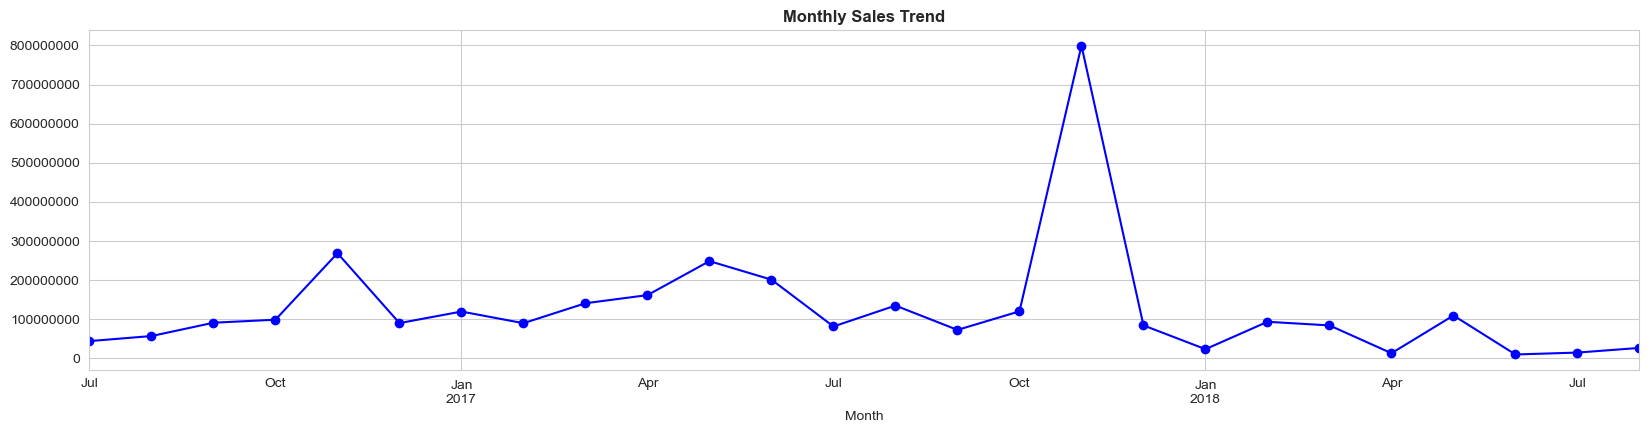

In [16]:
# edit draw paper
sns.set_style("whitegrid")
plt.figure(figsize=(20,15))
plt.subplot(3,1,3)

# Monthly sales trend
monthly_sales = file.groupby('month_year')['grand_total'].sum()
monthly_sales.plot(kind = 'line', marker = 'o', color = 'b')
plt.ticklabel_format(style='plain', axis='y') # ضيف السطر ده عشان يلغي الاختصار العلمي (1e8) ويظهر الرقم كامل
plt.title('Monthly Sales Trend', weight= 'bold')
plt.xlabel('Month')
plt.show()

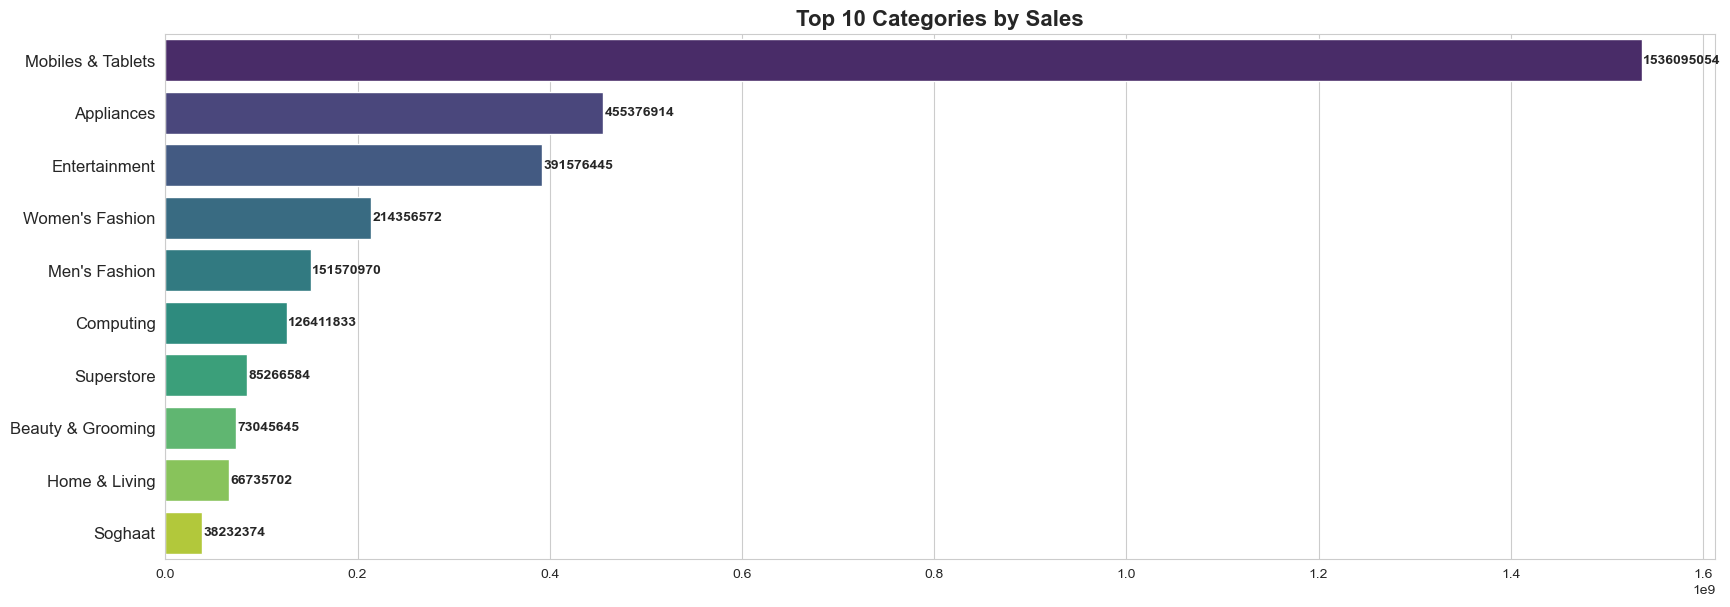

In [17]:
# edit draw paper
sns.set_style("whitegrid")
plt.figure(figsize=(20,15))

# Top 10 Categories by Sales
plt.subplot(2,1,2)
top_categories = file.groupby('category_name_1')['grand_total'].sum().sort_values(ascending=False).head(10)
ax = sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis', hue=top_categories.index  )
for container in ax.containers:
    ax.bar_label(container, fmt='%1.0f', padding=1, fontsize=10, weight= 'bold')
plt.title('Top 10 Categories by Sales', weight= 'bold', fontsize=16)
plt.yticks(fontsize=12)
plt.ylabel('')
plt.show()

In [18]:
file['payment_method'].value_counts()


payment_method
cod                  220028
Payaxis               80289
Easypay               57032
jazzwallet            30441
easypay_voucher       25979
jazzvoucher           13132
Easypay_MA             8519
bankalfalah            1505
ublcreditcard           882
cashatdoorstep          732
mcblite                 721
mygateway               669
internetbanking         472
apg                      99
marketingexpense         45
customercredit           39
financesettlement        15
Name: count, dtype: int64

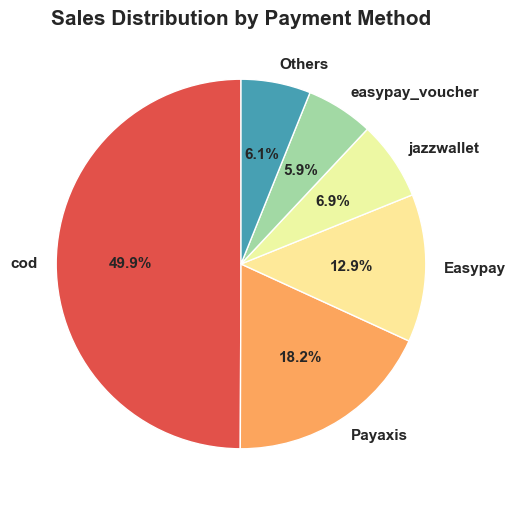

In [39]:
# edit draw paper
sns.set_style("whitegrid")
plt.figure(figsize=(15,6))

plt.subplot(1, 1, 1)

# prepare data to show only top 5 and group others
all_counts = file['payment_method'].value_counts()
# get top 5 
top_5 = all_counts.head(5)
# sum others
others = pd.Series([all_counts.iloc[5:].sum()], index=['Others'])
# combine top 5 and others
final_counts = pd.concat([top_5, others])

# draw pie chart
plt.pie(final_counts,
        colors=sns.color_palette('Spectral')[0:6], # ألوان القطع 
        labels=final_counts.index, # تسميات القطع
        autopct='%1.1f%%',       # إظهار النسبة المئوية
        startangle=90,          # تدوير الرسم 
        textprops={'fontsize': 11, 'weight': 'bold'} # تكبير الخط
        ) 

plt.title('Sales Distribution by Payment Method', fontsize=15, weight='bold')
plt.show()

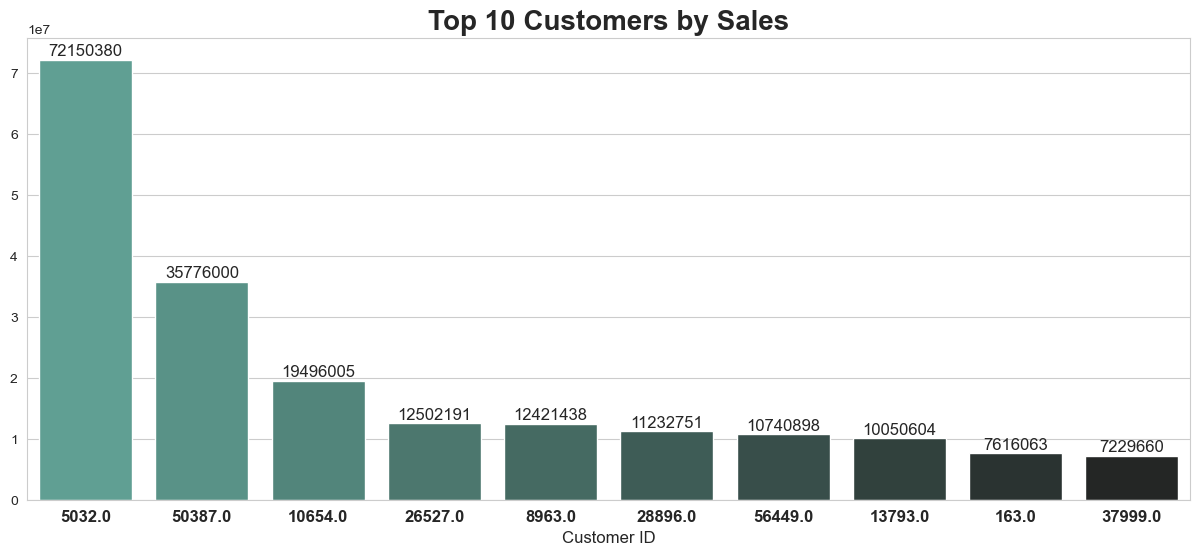

In [34]:
# top customers
sns.set_style("whitegrid")
plt.figure(figsize=(15,6)) 

plt.subplot(1,1,1)


top_customers = file.groupby('Customer ID')['grand_total'].sum().sort_values(ascending=False).head(10)

ax = sns.barplot(x = top_customers.index.astype(str), y = top_customers.values,palette='dark:#5A9_r', hue = top_customers.index.astype(str) )
for container in ax.containers:
    ax.bar_label(container, fmt='%1.0f', padding=1, fontsize=12 )

plt.title('Top 10 Customers by Sales', fontsize=20, weight = 'bold')
plt.xlabel('Customer ID', fontsize=12)
plt.xticks(fontsize=12, weight= 'bold')
plt.show()

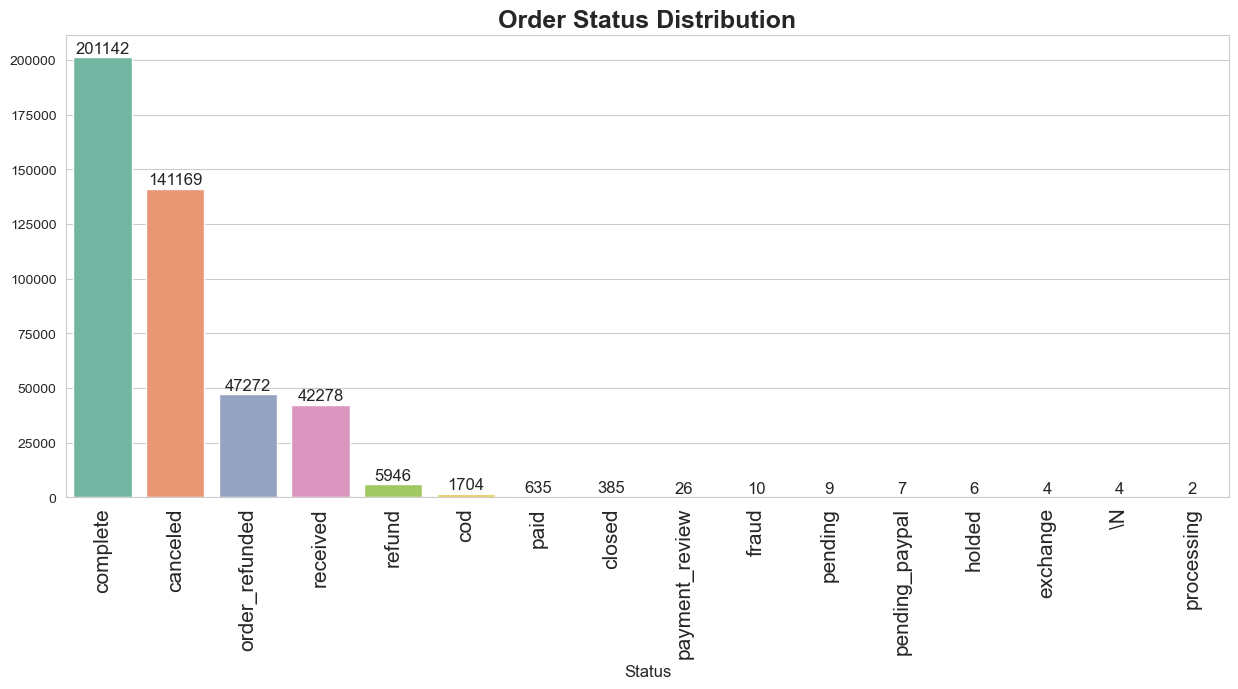

In [37]:
#Order Status Distribution
sns.set_style("whitegrid")
plt.figure(figsize=(15,6)) 

plt.subplot(1,1,1)

status_counts = file['status'].value_counts()
#draw
ax = sns.barplot(x = status_counts.index, y = status_counts.values, palette='Set2', hue = status_counts.index)
for container in ax.containers:
     ax.bar_label(container, fmt= '%1.0f', padding=1, fontsize=12)

plt.title('Order Status Distribution', fontsize = 18, weight = 'bold')
plt.xlabel('Status', fontsize=12)
plt.xticks(rotation= 90, fontsize=15)
plt.show()


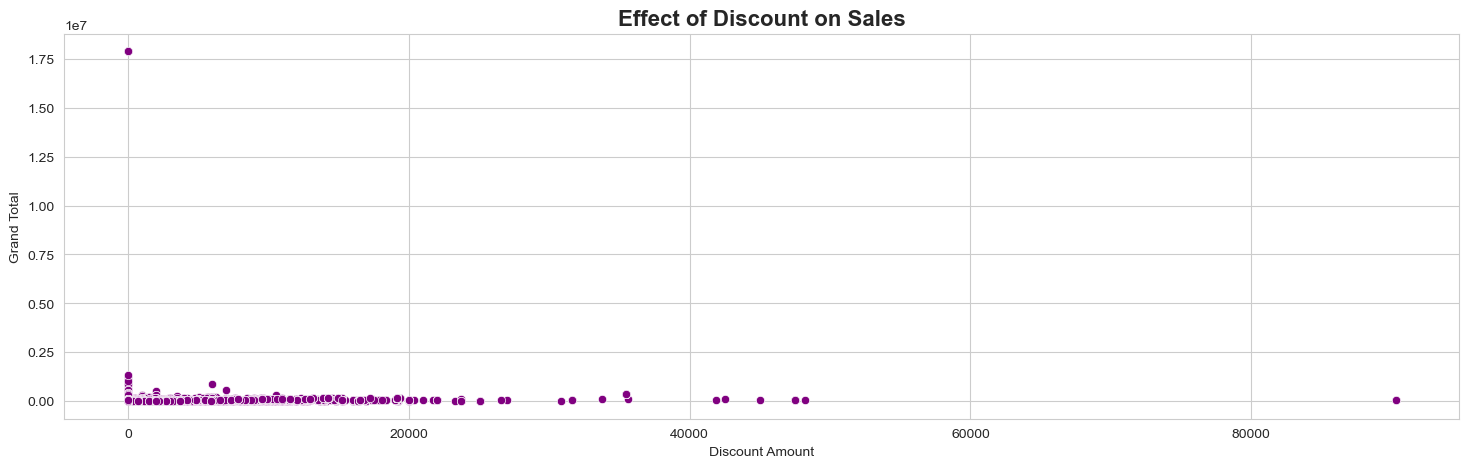

In [ ]:
# Discount vs Sales
sns.set_style("whitegrid")
plt.figure(figsize=(18,5)) 

plt.subplot(1,1,1)

sns.scatterplot(x='discount_amount', y='grand_total', data=file, color='purple')
plt.title('Effect of Discount on Sales', fontsize=16, weight = 'bold')
plt.xlabel('Discount Amount')
plt.ylabel('Grand Total')

plt.show()

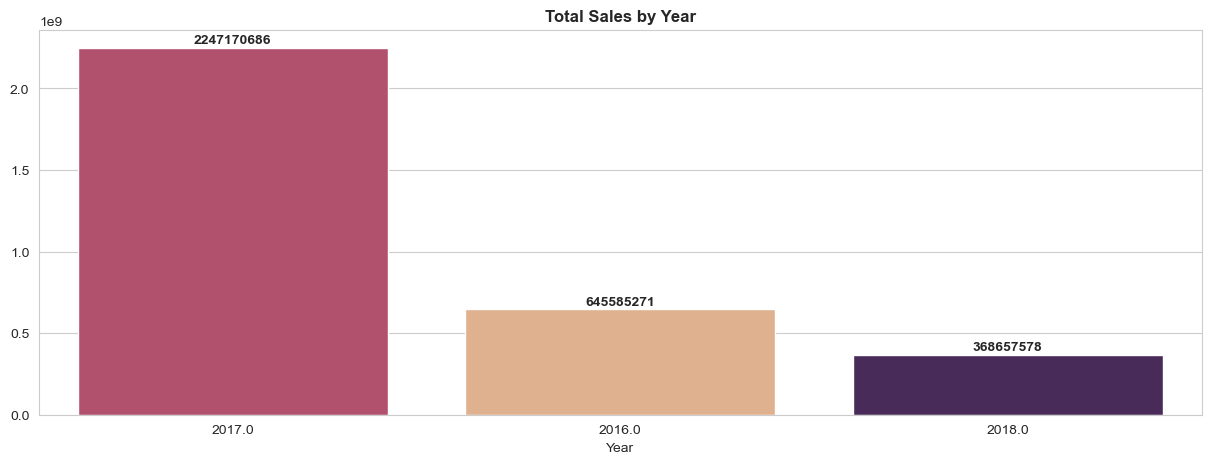

In [70]:
# Yearly Sales
sns.set_style("whitegrid")
plt.figure(figsize=(15,11)) 

plt.subplot(2,1,1)

yearly_sales = file.groupby('Year')['grand_total'].sum()
yearly_sales_sort = yearly_sales.sort_values(ascending=False)   

ax = sns.barplot(x=yearly_sales.index, y=yearly_sales.values, palette='flare', hue = yearly_sales.index, legend= False, order = yearly_sales_sort.index)

for container in ax.containers:
    ax.bar_label(container, fmt='%1.0f', padding=1, weight= 'bold')
plt.title('Total Sales by Year',weight= 'bold')
plt.show()

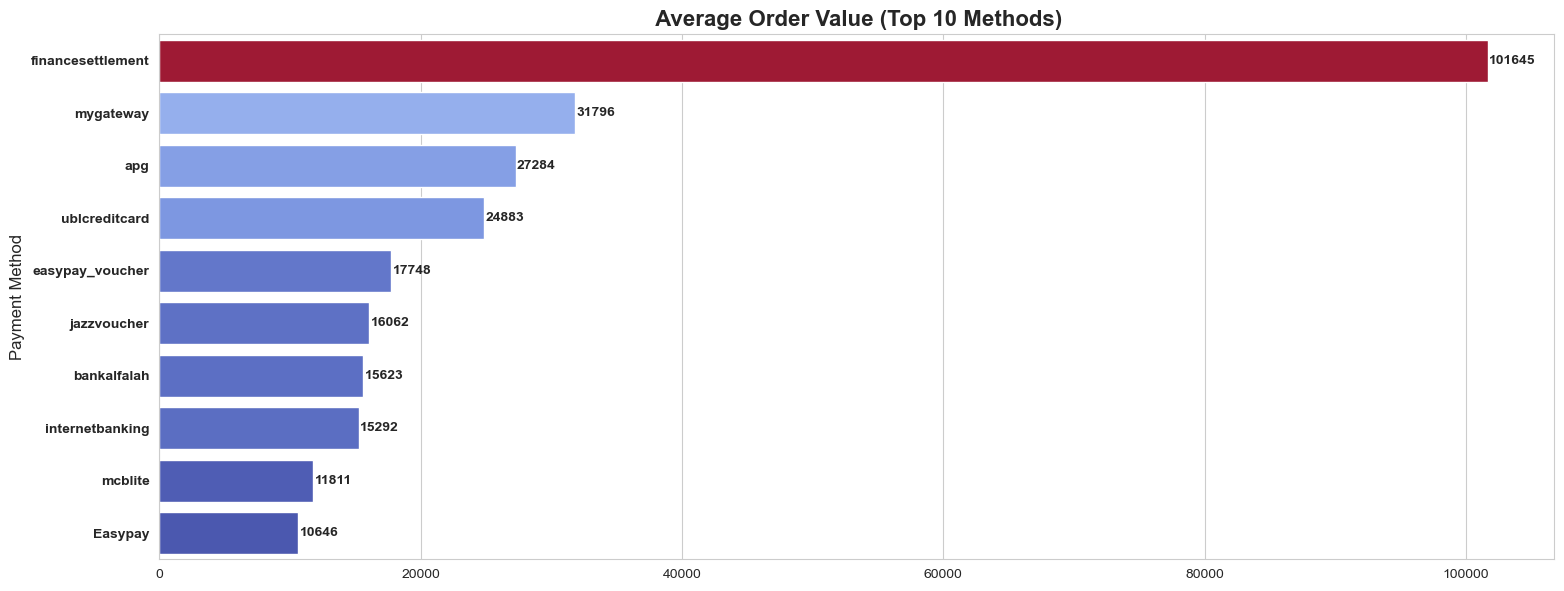

In [52]:
#Average Order Value
sns.set_style("whitegrid")
plt.figure(figsize=(18,15)) 

plt.subplot(2,1,2)

avg_order = file.groupby('payment_method')['grand_total'].mean().sort_values(ascending=False).head(10)

ax = sns.barplot(x=avg_order.values, y=avg_order.index, palette='coolwarm', hue = avg_order.values, legend= False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=1, weight= 'bold')
plt.title(' Average Order Value (Top 10 Methods)', fontsize=16, weight= 'bold')
plt.ylabel('Payment Method', fontsize=12)
plt.yticks(weight = 'bold')
plt.show()

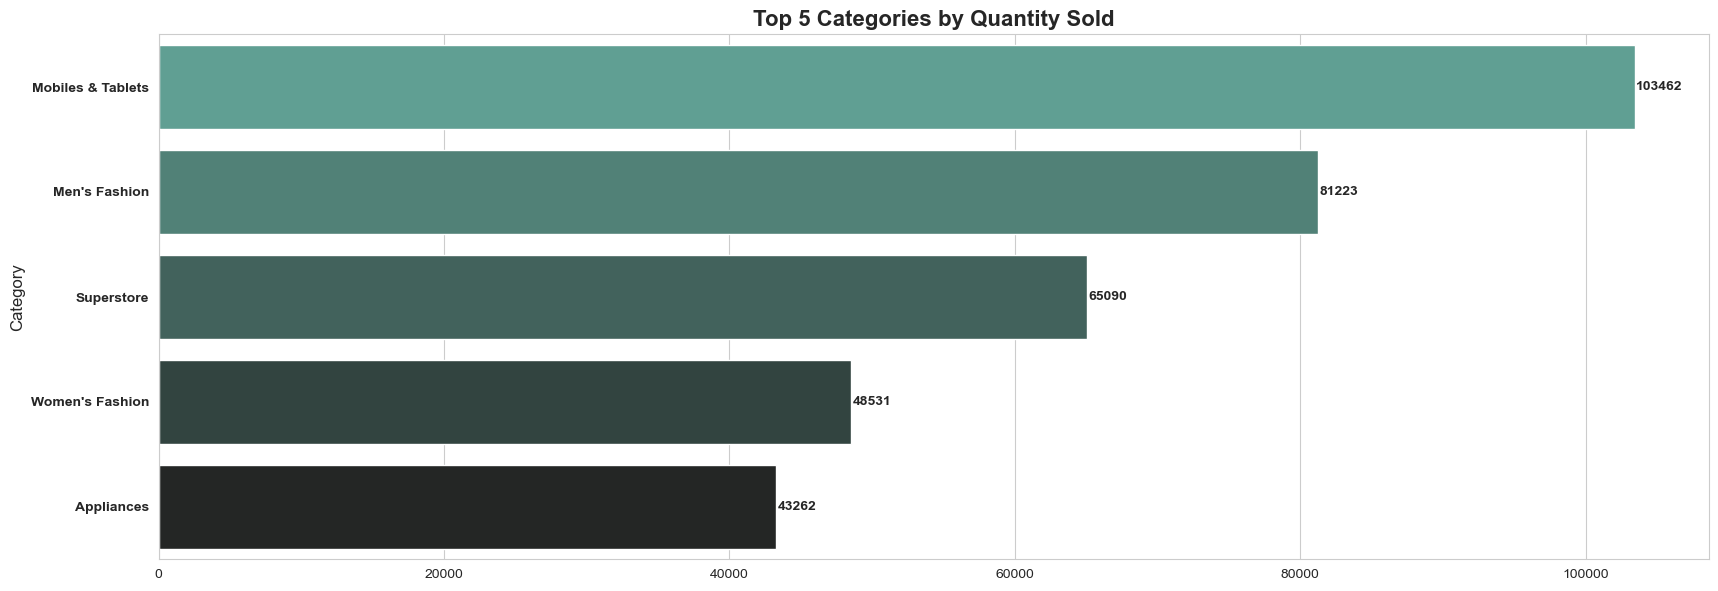

In [53]:
# Top Categories by Quantity
sns.set_style("whitegrid")
plt.figure(figsize=(20,15)) 

plt.subplot(2,1,1)

top_categories_qty = file.groupby('category_name_1')['qty_ordered'].sum().sort_values(ascending=False).head(5)

ax = sns.barplot(x=top_categories_qty.values, y=top_categories_qty.index, palette='dark:#5A9_r', hue=top_categories_qty.index)
for container in ax.containers:
    ax.bar_label(container, fmt='%1.0f', padding=1, weight= 'bold')

plt.title('Top 5 Categories by Quantity Sold', fontsize=16, weight= 'bold')
plt.ylabel('Category', fontsize=12)
plt.yticks(weight = 'bold')
plt.show()

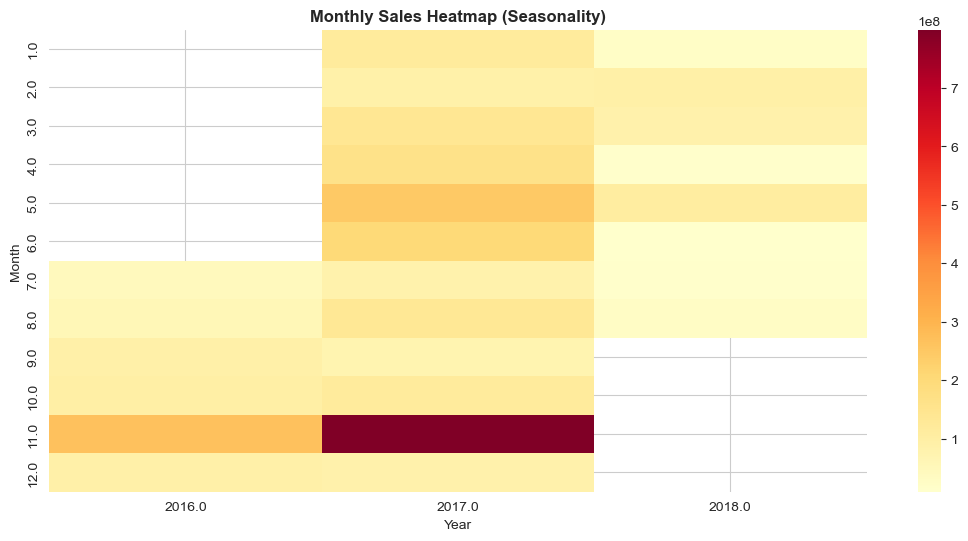

In [65]:
# Sales Heatmap
sns.set_style("whitegrid")
plt.figure(figsize=(29,6)) 

plt.subplot(1,2,1)

heatmap_data = file.pivot_table(index='Month', columns='Year', values='grand_total', aggfunc='sum')
sns.heatmap(heatmap_data, cmap='YlOrRd')

plt.title('Monthly Sales Heatmap (Seasonality)', weight= 'bold')

plt.show()

In [27]:
# save cleaned file 
#file.to_csv('cleaned_sales_data.csv', index = False)

## To Varifiy Data With SQL

In [28]:
print(file['grand_total'].sum())

3261413536.1215014


In [29]:
len(file)

440599

In [30]:
print(file[file['Year'] == 2017]['grand_total'].sum())

2247170686.413
